In [ ]:
import torch
from fun.models.fno_unet import FNOUNet
import matplotlib.pyplot as plt

In [2]:
test = FNOUNet(in_channels = 1, out_channels = 1, kbase1 = 128, kbase2 = 128, depth = 4, base_channels = 16)

summe = 0
for parameter in test.parameters():
    summe += parameter.numel()

print(summe)

test.to('cuda')

63064080


FNOUNet(
  (_FNOUNet__down_blocks): ModuleList(
    (0): Sequential(
      (0): SpectralConv2d_memory(1, 16, 128, 128)
      (1): ReLU()
      (2): SpectralConv2d_memory(16, 16, 128, 128)
      (3): ReLU()
    )
    (1): Sequential(
      (0): SpectralConv2d_memory(16, 16, 64, 64)
      (1): SpectralConv2d_memory(16, 32, 64, 64)
      (2): ReLU()
      (3): SpectralConv2d_memory(32, 32, 64, 64)
      (4): ReLU()
    )
    (2): Sequential(
      (0): SpectralConv2d_memory(32, 32, 32, 32)
      (1): SpectralConv2d_memory(32, 64, 32, 32)
      (2): ReLU()
      (3): SpectralConv2d_memory(64, 64, 32, 32)
      (4): ReLU()
    )
    (3): Sequential(
      (0): SpectralConv2d_memory(64, 64, 16, 16)
      (1): SpectralConv2d_memory(64, 128, 16, 16)
      (2): ReLU()
      (3): SpectralConv2d_memory(128, 128, 16, 16)
      (4): ReLU()
    )
  )
  (_FNOUNet__central_block): Sequential(
    (0): SpectralConv2d_memory(128, 128, 8, 8)
    (1): SpectralConv2d_memory(128, 256, 8, 8)
    (2): ReLU()


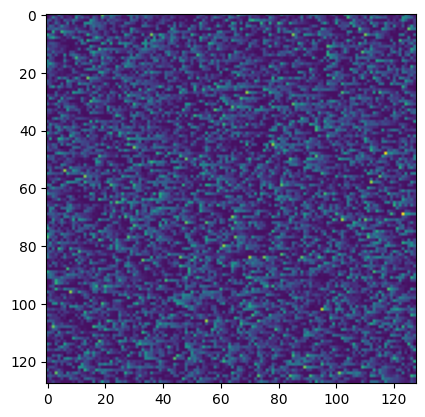

In [3]:
test_input = torch.randn((1,1,128,128), device = 'cuda')

test_output = test(test_input)

plt.imshow(test_output[0,0].cpu().detach().numpy())